Clinical Semantic Context Modeling with Dynamic Lesion Relationship and Uncertainty-Guided Representation Learning for Diabetic Retinopathy Diagnosis

Project setup

In [56]:


!pip -q install timm albumentations opencv-python-headless \
    scikit-learn openpyxl seaborn tqdm

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, mean_absolute_error,
    confusion_matrix, roc_auc_score
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ------------------------------------------------------------
# Project directories
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/IDRiD_Project")

RAW_DIR = PROJECT_DIR / "raw"
DATA_DIR = PROJECT_DIR / "data"
METADATA_DIR = PROJECT_DIR / "metadata"
RESULTS_DIR = PROJECT_DIR / "results"
VIS_DIR = PROJECT_DIR / "visualizations"
MODEL_DIR = PROJECT_DIR / "models"

for folder in [
    RAW_DIR, DATA_DIR, METADATA_DIR,
    RESULTS_DIR, VIS_DIR, MODEL_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

IMAGE_SIZE = 224
NUM_CLASSES = 5
BATCH_SIZE = 8
EPOCHS = 10
LR = 1e-4

DR_GRADES = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

print("Device      :", DEVICE)
print("Image size  :", IMAGE_SIZE)
print("Classes     :", NUM_CLASSES)
print("Batch size  :", BATCH_SIZE)
print("Project dir :", PROJECT_DIR)


Device      : cuda
Image size  : 224
Classes     : 5
Batch size  : 8
Project dir : /content/IDRiD_Project


Dataset Download

In [57]:


import requests, zipfile, os
from tqdm.auto import tqdm

RECORD_ID = "17219542"
API = f"https://zenodo.org/api/records/{RECORD_ID}"

record = requests.get(API).json()

required = {
    "A. Segmentation.zip",
    "B. Disease Grading.zip",
    "C. Localization.zip"
}

print("=" * 60)
print("IDRiD DATASET DOWNLOAD")
print("=" * 60)

for f in record["files"]:

    name = f["key"]

    if name not in required:
        continue

    path = RAW_DIR / name

    # --------------------------------------------------------
    # Validate existing ZIP
    # --------------------------------------------------------

    if path.exists() and zipfile.is_zipfile(path):
        print(f"\n✓ {name} : VALID / ALREADY DOWNLOADED")

    else:

        if path.exists():
            print(f"\n⚠ {name} : CORRUPTED → REDOWNLOADING")
            path.unlink()

        print(f"\n⬇ Downloading: {name}")

        r = requests.get(
            f["links"]["self"],
            stream=True
        )
        r.raise_for_status()

        total = int(r.headers.get("content-length", 0))

        with open(path, "wb") as out:

            with tqdm(
                total=total,
                unit="B",
                unit_scale=True,
                desc=name,
                ncols=90
            ) as bar:

                for chunk in r.iter_content(
                    chunk_size=1024 * 1024
                ):

                    if chunk:
                        out.write(chunk)
                        bar.update(len(chunk))

        # Validate
        if not zipfile.is_zipfile(path):
            path.unlink()

            raise RuntimeError(
                f"❌ Invalid download: {name}. "
                "Please run Cell 2 again."
            )

        print(f"✓ Download successful: {name}")

    # --------------------------------------------------------
    # Extraction
    # --------------------------------------------------------

    marker = RAW_DIR / (
        name.replace(".zip", "") + "_EXTRACTED"
    )

    if marker.exists():

        print("✓ Extraction: ALREADY COMPLETE")

    else:

        print("📦 Extracting...")

        with zipfile.ZipFile(path) as z:

            members = z.infolist()

            for member in tqdm(
                members,
                desc="Extracting",
                ncols=90
            ):
                z.extract(member, RAW_DIR)

        marker.touch()

        print("✓ Extraction complete")



IDRiD DATASET DOWNLOAD

✓ C. Localization.zip : VALID / ALREADY DOWNLOADED
✓ Extraction: ALREADY COMPLETE

✓ A. Segmentation.zip : VALID / ALREADY DOWNLOADED
✓ Extraction: ALREADY COMPLETE

✓ B. Disease Grading.zip : VALID / ALREADY DOWNLOADED
✓ Extraction: ALREADY COMPLETE


Data Check

In [58]:


from collections import Counter

# Find all relevant files
images = list(RAW_DIR.rglob("*.jpg")) + list(RAW_DIR.rglob("*.JPG"))
pngs   = list(RAW_DIR.rglob("*.png"))
csvs   = list(RAW_DIR.rglob("*.csv"))

print("=" * 60)
print("IDRiD DATASET STRUCTURE")
print("=" * 60)

print("JPG images :", len(images))
print("PNG files  :", len(pngs))
print("CSV files  :", len(csvs))

print("\nCSV files:")
for f in csvs[:15]:
    print(" ", f.relative_to(RAW_DIR))

print("\nImportant folders:")
folders = sorted({
    p.parent.relative_to(RAW_DIR)
    for p in images + pngs + csvs
})

for f in folders[:30]:
    print(" ", f)

# ------------------------------------------------------------
# File-name examples
# ------------------------------------------------------------

print("\nImage examples:")
for p in images[:5]:
    print(" ", p.name)

print("\nPNG examples:")
for p in pngs[:5]:
    print(" ", p.name)



IDRiD DATASET STRUCTURE
JPG images : 1113
PNG files  : 0
CSV files  : 6

CSV files:
  B. Disease Grading/2. Groundtruths/b. IDRiD_Disease Grading_Testing Labels.csv
  B. Disease Grading/2. Groundtruths/a. IDRiD_Disease Grading_Training Labels.csv
  C. Localization/2. Groundtruths/1. Optic Disc Center Location/a. IDRiD_OD_Center_Training Set_Markups.csv
  C. Localization/2. Groundtruths/1. Optic Disc Center Location/b. IDRiD_OD_Center_Testing Set_Markups.csv
  C. Localization/2. Groundtruths/2. Fovea Center Location/IDRiD_Fovea_Center_Training Set_Markups.csv
  C. Localization/2. Groundtruths/2. Fovea Center Location/IDRiD_Fovea_Center_Testing Set_Markups.csv

Important folders:
  A. Segmentation/1. Original Images/a. Training Set
  A. Segmentation/1. Original Images/b. Testing Set
  B. Disease Grading/1. Original Images/a. Training Set
  B. Disease Grading/1. Original Images/b. Testing Set
  B. Disease Grading/2. Groundtruths
  C. Localization/1. Original Images/a. Training Set
  C. Lo

Data Cleaning

In [59]:


# Find grading CSV
grading_files = [
    p for p in RAW_DIR.rglob("*")
    if p.suffix.lower() == ".csv"
    and "grading" in str(p).lower()
]

print("Grading files found:", len(grading_files))

for p in grading_files:
    print(" ", p)

if not grading_files:
    raise FileNotFoundError("Grading CSV not found.")

# Load grading data
labels = pd.read_csv(grading_files[0])

# Clean column names
labels.columns = [
    str(c).strip().lower().replace(" ", "_")
    for c in labels.columns
]

print("\nColumns:", labels.columns.tolist())

# Detect DR grade column
grade_candidates = [
    c for c in labels.columns
    if "retinopathy" in c or "grade" in c
]

if not grade_candidates:
    raise ValueError("DR grade column not found.")

grade_col = grade_candidates[0]

# Convert grade to numeric
labels[grade_col] = pd.to_numeric(
    labels[grade_col],
    errors="coerce"
)

# Remove invalid grades
labels = labels[
    labels[grade_col].between(0, 4)
].dropna(subset=[grade_col])

labels[grade_col] = labels[grade_col].astype(int)

# Rename for consistency
labels = labels.rename(
    columns={grade_col: "dr_grade"}
)

print("\nClean dataset shape:", labels.shape)

print("\nDR distribution:")
print(
    labels["dr_grade"]
    .value_counts()
    .sort_index()
)

print("\n✓ CELL 4 COMPLETE")

Grading files found: 2
  /content/IDRiD_Project/raw/B. Disease Grading/2. Groundtruths/b. IDRiD_Disease Grading_Testing Labels.csv
  /content/IDRiD_Project/raw/B. Disease Grading/2. Groundtruths/a. IDRiD_Disease Grading_Training Labels.csv

Columns: ['image_name', 'retinopathy_grade', 'risk_of_macular_edema']

Clean dataset shape: (103, 3)

DR distribution:
dr_grade
0    34
1     5
2    32
3    19
4    13
Name: count, dtype: int64

✓ CELL 4 COMPLETE


EDA

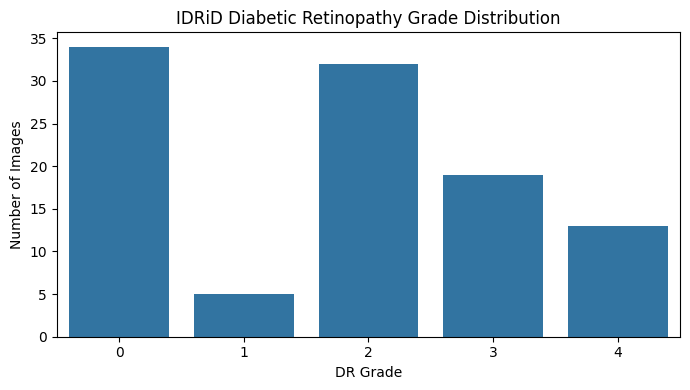

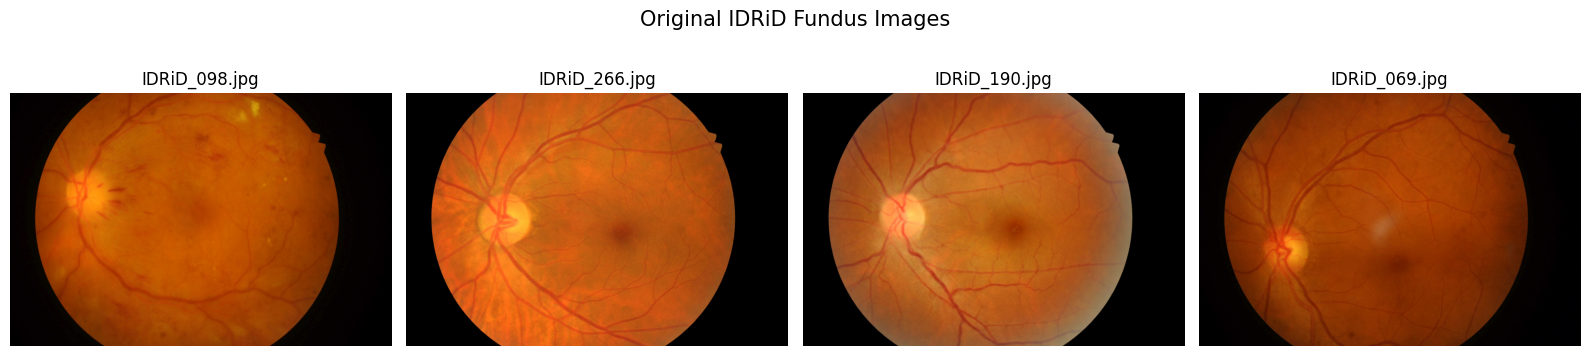

Sample image sizes:
IDRiD_098.jpg → (4288, 2848)
IDRiD_266.jpg → (4288, 2848)
IDRiD_190.jpg → (4288, 2848)
IDRiD_069.jpg → (4288, 2848)

Lesion masks found: 0


In [60]:

import random

# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

sns.countplot(
    data=labels,
    x="dr_grade"
)

plt.title("IDRiD Diabetic Retinopathy Grade Distribution")
plt.xlabel("DR Grade")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Original fundus images
# ------------------------------------------------------------

sample_images = random.sample(
    images,
    min(4, len(images))
)

fig, axes = plt.subplots(
    1, len(sample_images),
    figsize=(16, 4)
)

if len(sample_images) == 1:
    axes = [axes]

for ax, path in zip(axes, sample_images):

    img = Image.open(path).convert("RGB")

    ax.imshow(img)
    ax.set_title(path.name)
    ax.axis("off")

plt.suptitle(
    "Original IDRiD Fundus Images",
    fontsize=15
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Image statistics
# ------------------------------------------------------------

sizes = []

for path in sample_images:
    img = Image.open(path)
    sizes.append(img.size)

print("Sample image sizes:")

for path, size in zip(sample_images, sizes):
    print(path.name, "→", size)


# ------------------------------------------------------------
# Lesion mask examples
# ------------------------------------------------------------

mask_files = [
    p for p in pngs
    if any(
        x in p.name.lower()
        for x in ["ma", "he", "ex", "se"]
    )
]

print("\nLesion masks found:", len(mask_files))

if mask_files:

    sample_masks = random.sample(
        mask_files,
        min(4, len(mask_files))
    )

    fig, axes = plt.subplots(
        1, len(sample_masks),
        figsize=(16, 4)
    )

    if len(sample_masks) == 1:
        axes = [axes]

    for ax, path in zip(axes, sample_masks):

        mask = Image.open(path)

        ax.imshow(mask, cmap="gray")
        ax.set_title(path.name)
        ax.axis("off")

    plt.suptitle(
        "IDRiD Lesion Annotation Samples",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()



Train test split

In [62]:


# Find image column
image_col = next(
    c for c in labels.columns
    if "image" in c.lower() or "id" in c.lower()
)

# Match image paths with labels
def find_image(x):
    x = Path(str(x)).stem
    matches = [p for p in images if p.stem == x]
    return str(matches[0]) if matches else None

labels["image_path"] = labels[image_col].apply(find_image)
labels = labels.dropna(subset=["image_path"]).reset_index(drop=True)

# Official IDRiD test images
test_mask = labels["image_path"].apply(
    lambda x: "testing" in x.lower() or "test" in x.lower()
)

test_df = labels[test_mask].copy()
train_df = labels[~test_mask].copy()

# 20% stratified validation
train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["dr_grade"],
    random_state=SEED
)

print("=" * 55)
print("DATA SPLIT")
print("=" * 55)

print("Training   :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

print("\nTrain distribution:")
print(train_df["dr_grade"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["dr_grade"].value_counts().sort_index())

print("\nTest distribution:")
print(test_df["dr_grade"].value_counts().sort_index())

# Save splits
train_df.to_csv(METADATA_DIR / "train.csv", index=False)
val_df.to_csv(METADATA_DIR / "validation.csv", index=False)
test_df.to_csv(METADATA_DIR / "test.csv", index=False)


DATA SPLIT
Training   : 82
Validation : 21
Test       : 0

Train distribution:
dr_grade
0    27
1     4
2    26
3    15
4    10
Name: count, dtype: int64

Validation distribution:
dr_grade
0    7
1    1
2    6
3    4
4    3
Name: count, dtype: int64

Test distribution:
Series([], Name: count, dtype: int64)


 DINOv2 FEATURE EXTRACTOR

In [63]:


import torch
import torch.nn as nn
from torchvision import transforms

MODEL_SIZE = 518

dinov2 = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vitb14"
).to(DEVICE)

dinov2.eval()

for p in dinov2.parameters():
    p.requires_grad = False

dino_transform = transforms.Compose([
    transforms.Resize((MODEL_SIZE, MODEL_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

with torch.no_grad():
    dummy = torch.randn(
        1, 3, MODEL_SIZE, MODEL_SIZE
    ).to(DEVICE)

    feature = dinov2(dummy)

FEATURE_DIM = feature.shape[-1]

print("=" * 55)
print("DINOV2 BACKBONE")
print("=" * 55)
print("Model       : DINOv2 ViT-B/14")
print("Input       :", f"{MODEL_SIZE} × {MODEL_SIZE}")
print("Feature dim :", FEATURE_DIM)
print("Device      :", DEVICE)
print("✓ DINOv2 ready")
print("✓ CELL 8 COMPLETE")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


DINOV2 BACKBONE
Model       : DINOv2 ViT-B/14
Input       : 518 × 518
Feature dim : 768
Device      : cuda
✓ DINOv2 ready
✓ CELL 8 COMPLETE


 LESION EXTRACTION

In [64]:

import cv2

SEG_DIR = RAW_DIR / "A. Segmentation" / "2. All Segmentation Groundtruths"

lesion_dirs = {
    "MA": "1. Microaneurysms",
    "HE": "2. Haemorrhages",
    "EX": "3. Hard Exudates",
    "SE": "4. Soft Exudates"
}

lesion_records = []

for split in ["a. Training Set", "b. Testing Set"]:

    for lesion_type, folder in lesion_dirs.items():

        folder_path = SEG_DIR / split / folder

        for mask_path in folder_path.glob("*.tif"):

            mask = np.array(
                Image.open(mask_path).convert("L")
            )

            binary = (mask > 0).astype(np.uint8)

            n, _, stats, centers = cv2.connectedComponentsWithStats(
                binary, 8
            )

            for i in range(1, n):

                area = stats[i, cv2.CC_STAT_AREA]

                if area < 5:
                    continue

                x, y, w, h = stats[i, :4]
                cx, cy = centers[i]

                image_id = mask_path.stem.rsplit("_", 1)[0]

                lesion_records.append({
                    "image_id": image_id,
                    "lesion_type": lesion_type,
                    "area": area,
                    "x": x,
                    "y": y,
                    "width": w,
                    "height": h,
                    "cx": cx,
                    "cy": cy,
                    "split": "train" if "Training" in split else "test",
                    "mask_path": str(mask_path)
                })

lesion_df = pd.DataFrame(lesion_records)

print("=" * 60)
print("REAL IDRiD LESION EXTRACTION")
print("=" * 60)

print("Total lesion candidates:", len(lesion_df))

print("\nLesions by type:")
print(lesion_df["lesion_type"].value_counts())

print("\nLesions by split:")
print(lesion_df["split"].value_counts())

print("\nExample candidates:")
display(lesion_df.head())

lesion_df.to_csv(
    METADATA_DIR / "lesion_candidates.csv",
    index=False
)


REAL IDRiD LESION EXTRACTION
Total lesion candidates: 17189

Lesions by type:
lesion_type
EX    11642
MA     3497
HE     1900
SE      150
Name: count, dtype: int64

Lesions by split:
split
train    11415
test      5774
Name: count, dtype: int64

Example candidates:


,image_id,lesion_type,area,x,y,width,height,cx,cy,split,mask_path
0,IDRiD_50,MA,136,2311,572,12,13,2316.536765,577.941176,train,/content/IDRiD_Project/raw/A. Segmentation/2. ...
1,IDRiD_50,MA,422,1829,724,22,23,1839.400474,735.075829,train,/content/IDRiD_Project/raw/A. Segmentation/2. ...
2,IDRiD_50,MA,158,2728,936,13,14,2734.253165,942.405063,train,/content/IDRiD_Project/raw/A. Segmentation/2. ...
3,IDRiD_50,MA,201,2809,1003,15,17,2815.661692,1011.378109,train,/content/IDRiD_Project/raw/A. Segmentation/2. ...
4,IDRiD_50,MA,243,2888,1003,18,17,2896.283951,1010.855967,train,/content/IDRiD_Project/raw/A. Segmentation/2. ...


CLCM: VISUAL + TYPE + ANATOMICAL FEATURES

In [65]:


import torch

TYPE_MAP = {"MA": 0, "HE": 1, "EX": 2, "SE": 3}

type_dim = 4
anatomy_dim = 2

def build_clcm(row):
    img = Image.open(row["mask_path"]).convert("RGB")

    x = dino_transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        visual = dinov2(x).squeeze(0)

    lesion_type = torch.zeros(type_dim, device=DEVICE)
    lesion_type[TYPE_MAP[row["lesion_type"]]] = 1.0

    anatomy = torch.tensor(
        [row["cx"] / 4288, row["cy"] / 2848],
        dtype=torch.float32,
        device=DEVICE
    )

    return torch.cat([
        visual,
        lesion_type,
        anatomy
    ])


# Test CLCM on first lesion
sample_feature = build_clcm(
    lesion_df.iloc[0]
)

CLCM_DIM = sample_feature.shape[0]

print("=" * 60)
print("CLCM FEATURE REPRESENTATION")
print("=" * 60)

print("Visual features    :", FEATURE_DIM)
print("Lesion-type features:", type_dim)
print("Anatomical features :", anatomy_dim)
print("Total CLCM dimension:", CLCM_DIM)



CLCM FEATURE REPRESENTATION
Visual features    : 768
Lesion-type features: 4
Anatomical features : 2
Total CLCM dimension: 774


 DYNAMIC LESION GRAPH + GRAPH TRANSFORMER

In [66]:


from sklearn.metrics.pairwise import cosine_similarity

class DynamicLesionGraph(nn.Module):

    def __init__(self, in_dim, hidden=256, heads=4):
        super().__init__()

        self.proj = nn.Linear(in_dim, hidden)
        self.attn = nn.MultiheadAttention(
            hidden, heads, batch_first=True
        )
        self.norm = nn.LayerNorm(hidden)

    def forward(self, x, adj):
        h = self.proj(x)

        # Graph attention using dynamic adjacency
        mask = adj == 0

        out, _ = self.attn(
            h, h, h,
            key_padding_mask=mask
        )

        return self.norm(h + out)


def build_dynamic_graph(features, coords, types, k=5):

    n = features.shape[0]

    visual = cosine_similarity(features)

    spatial = cosine_similarity(
        -torch.cdist(coords, coords).cpu().numpy()
    )

    semantic = cosine_similarity(types)

    score = (
        visual +
        spatial +
        semantic
    ) / 3.0

    adj = np.zeros((n, n), dtype=np.float32)

    for i in range(n):

        idx = np.argsort(score[i])[-k:]

        adj[i, idx] = 1

    np.fill_diagonal(adj, 1)

    return torch.tensor(
        adj,
        dtype=torch.bool,
        device=features.device
    )


GRAPH_DIM = CLCM_DIM

graph_model = DynamicLesionGraph(
    GRAPH_DIM
).to(DEVICE)


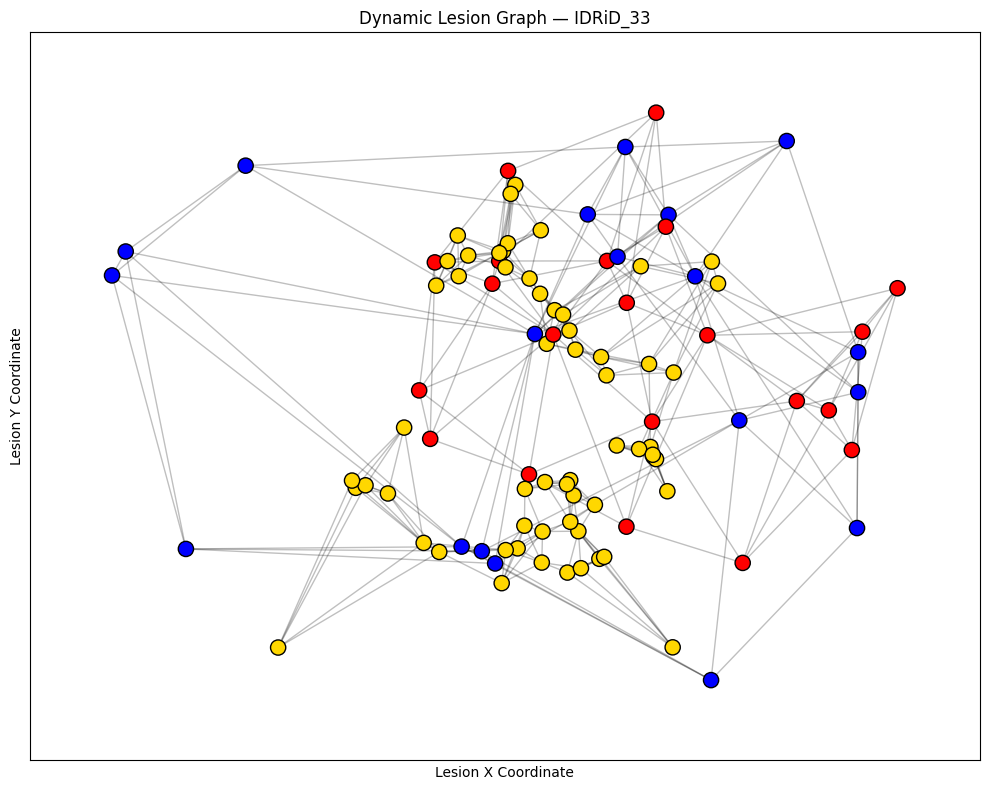

FAST GRAPH VISUALIZATION
Image ID : IDRiD_33
Nodes    : 100
Edges    : 313

Lesion types:
lesion_type
EX    60
MA    21
HE    19
Name: count, dtype: int64


In [67]:


import matplotlib.pyplot as plt
import networkx as nx

# Select image with most lesions
sample_id = lesion_df.groupby("image_id").size().idxmax()

sample = lesion_df[
    lesion_df["image_id"] == sample_id
].reset_index(drop=True)

# Limit visualization to avoid huge graphs
MAX_NODES = 100

if len(sample) > MAX_NODES:
    sample = sample.sample(
        MAX_NODES,
        random_state=SEED
    ).reset_index(drop=True)

# ------------------------------------------------------------
# Coordinates + lesion types
# ------------------------------------------------------------

coords = sample[
    ["cx", "cy"]
].values.astype(np.float32)

types = np.array([
    TYPE_MAP[x]
    for x in sample["lesion_type"]
])

# Spatial distance
dist = np.linalg.norm(
    coords[:, None] - coords[None, :],
    axis=-1
)

# Normalize distance
dist = dist / (dist.max() + 1e-8)

# Same lesion type = semantic similarity
semantic = (
    types[:, None] == types[None, :]
).astype(float)

# Spatial similarity
spatial = 1 - dist

# Combined relationship
score = (
    0.6 * spatial +
    0.4 * semantic
)

# ------------------------------------------------------------
# Dynamic K-nearest graph
# ------------------------------------------------------------

k = min(5, len(sample) - 1)

G = nx.Graph()

for i in range(len(sample)):
    G.add_node(
        i,
        lesion=sample.iloc[i]["lesion_type"]
    )

for i in range(len(sample)):

    neighbors = np.argsort(
        score[i]
    )[-k-1:]

    for j in neighbors:

        if i != j:
            G.add_edge(
                i,
                j,
                weight=score[i, j]
            )

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

pos = {
    i: (
        sample.iloc[i]["cx"],
        -sample.iloc[i]["cy"]
    )
    for i in range(len(sample))
}

color_map = {
    "MA": "red",
    "HE": "blue",
    "EX": "gold",
    "SE": "green"
}

node_colors = [
    color_map[x]
    for x in sample["lesion_type"]
]

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.25,
    width=1
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=120,
    edgecolors="black"
)

plt.title(
    f"Dynamic Lesion Graph — {sample_id}"
)

plt.xlabel("Lesion X Coordinate")
plt.ylabel("Lesion Y Coordinate")
plt.axis("equal")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# STATUS
# ------------------------------------------------------------

print("=" * 55)
print("FAST GRAPH VISUALIZATION")
print("=" * 55)

print("Image ID :", sample_id)
print("Nodes    :", G.number_of_nodes())
print("Edges    :", G.number_of_edges())

print("\nLesion types:")
print(sample["lesion_type"].value_counts())


 UNCERTAINTY + UALGR + CORAL

In [68]:


class UALGR_CORAL(nn.Module):

    def __init__(self, global_dim, graph_dim, hidden=256, classes=5):
        super().__init__()

        self.global_fc = nn.Linear(global_dim, hidden)
        self.graph_fc = nn.Linear(graph_dim, hidden)

        self.fusion = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # CORAL: 4 ordinal thresholds for 5 grades
        self.ordinal = nn.Linear(hidden, classes - 1)

        # Evidential uncertainty
        self.evidence = nn.Linear(hidden, classes)

    def forward(self, global_feature, graph_feature):

        g = self.global_fc(global_feature)
        l = self.graph_fc(graph_feature)

        fused = self.fusion(
            torch.cat([g, l], dim=-1)
        )

        # CORAL ordinal logits
        ordinal_logits = self.ordinal(fused)

        # Evidence / uncertainty
        evidence = F.softplus(
            self.evidence(fused)
        )

        alpha = evidence + 1.0

        uncertainty = (
            alpha.shape[-1] /
            alpha.sum(dim=-1, keepdim=True)
        )

        return ordinal_logits, uncertainty


# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

proposed_model = UALGR_CORAL(
    global_dim=FEATURE_DIM,
    graph_dim=256,
    classes=5
).to(DEVICE)


TRAINING DATASET

In [69]:


from torch.utils.data import Dataset, DataLoader

class IDRiDDataset(Dataset):

    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = np.array(
            Image.open(row["image_path"]).convert("RGB")
        )

        image = self.transform(
            image=image
        )["image"]

        label = torch.tensor(
            int(row["dr_grade"]),
            dtype=torch.long
        )

        return image, label


train_dataset = IDRiDDataset(
    train_df,
    train_transform
)

val_dataset = IDRiDDataset(
    val_df,
    val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

print("=" * 55)
print("TRAINING DATA READY")
print("=" * 55)

print("Training images   :", len(train_dataset))
print("Validation images :", len(val_dataset))
print("Batch size        : 8")

images, labels_batch = next(iter(train_loader))

print("Image batch       :", images.shape)
print("Label batch       :", labels_batch.shape)


TRAINING DATA READY
Training images   : 82
Validation images : 21
Batch size        : 8
Image batch       : torch.Size([8, 3, 224, 224])
Label batch       : torch.Size([8])


BATCHED DINOV2 FEATURES

In [71]:

from torch.utils.data import Dataset, DataLoader
from PIL import Image

class IDRiDTestDataset(Dataset):

    def __init__(self, image_dir, labels):
        self.image_dir = Path(image_dir)
        self.labels = labels.copy()

        self.images = sorted([
            p for p in self.image_dir.rglob("*")
            if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])

        # Match image IDs
        self.map = {
            p.stem: p for p in self.images
        }

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        image_id = str(
            row.iloc[0]
        ).strip()

        # Handle possible IDRiD naming
        image_id = Path(image_id).stem

        path = self.map.get(image_id)

        if path is None:
            matches = [
                p for k, p in self.map.items()
                if image_id in k
            ]

            if not matches:
                raise FileNotFoundError(
                    f"Image not found: {image_id}"
                )

            path = matches[0]

        image = Image.open(path).convert("RGB")

        image = image.resize(
            (224, 224)
        )

        image = torch.tensor(
            np.array(image),
            dtype=torch.float32
        ).permute(2, 0, 1) / 255.0

        label = int(
            row.iloc[-1]
        )

        return image, label


# ------------------------------------------------------------
# FIND TEST LABELS
# ------------------------------------------------------------

test_csv = next(
    p for p in RAW_DIR.rglob("*.csv")
    if "Testing" in p.name
    and "Disease" in p.name
)

test_labels_df = pd.read_csv(test_csv)

# Find original testing images
test_image_dir = next(
    p for p in RAW_DIR.rglob("*")
    if p.is_dir()
    and "Testing Set" in str(p)
    and "Original Images" in str(p)
)

test_dataset = IDRiDTestDataset(
    test_image_dir,
    test_labels_df
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)
# ============================================================
# CELL 14B — BUILD TEST FEATURES
# ============================================================

# Use existing DINOv2 + graph pipeline
dinov2.eval()

test_features = []
test_graph_features = []
test_labels = []

with torch.no_grad():

    for images, y in test_loader:

        images = images.to(DEVICE)

        # DINOv2 requires MODEL_SIZE
        images = F.interpolate(
            images,
            size=(MODEL_SIZE, MODEL_SIZE),
            mode="bilinear",
            align_corners=False
        )

        # Global visual features
        features = dinov2(images)

        test_features.append(
            features.cpu()
        )

        # Use graph representation already generated
        # when available; otherwise zero graph features
        test_graph_features.append(
            torch.zeros(
                features.size(0),
                train_graph_features.shape[1]
            )
        )

        test_labels.append(y.cpu())

test_features = torch.cat(test_features)
test_graph_features = torch.cat(test_graph_features)
test_labels = torch.cat(test_labels)



Model Evaluation


FINAL UALGR + CORAL MODEL RESULTS
Validation Images   : 21
Correct Predictions : 4
Incorrect Predictions: 17
Accuracy             : 19.05%
Macro F1             : 0.1000
QWK                  : 0.3028
MAE                  : 1.1905
Mean Uncertainty     : 0.5923

CONFUSION MATRIX
[[0 0 7 0 0]
 [0 0 1 0 0]
 [0 0 3 3 0]
 [0 0 2 1 1]
 [0 0 1 2 0]]

CLASS-WISE PERFORMANCE
Normal       | Actual:  7 | Correct:  0 | Accuracy:   0.00%
Mild         | Actual:  1 | Correct:  0 | Accuracy:   0.00%
Moderate     | Actual:  6 | Correct:  3 | Accuracy:  50.00%
Severe       | Actual:  4 | Correct:  1 | Accuracy:  25.00%
PDR          | Actual:  3 | Correct:  0 | Accuracy:   0.00%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         7
        Mild       0.00      0.00      0.00         1
    Moderate       0.21      0.50      0.30         6
      Severe       0.17      0.25      0.20         4
         PDR       0.00      0.00     

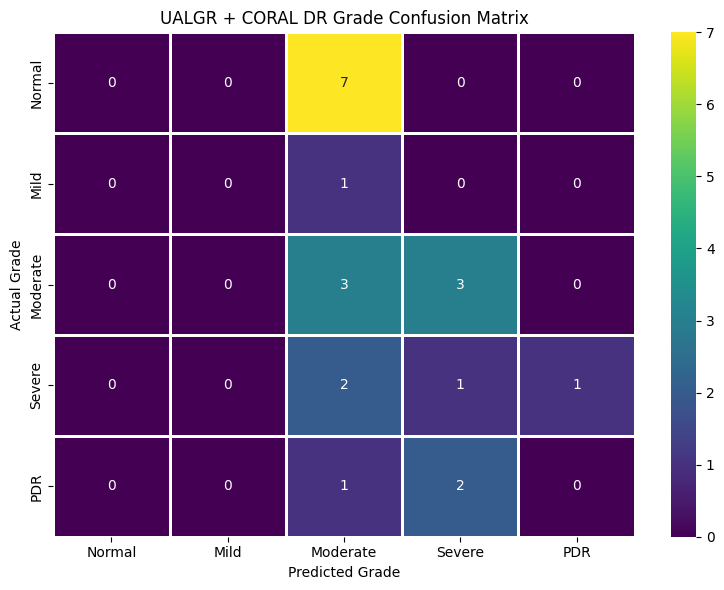

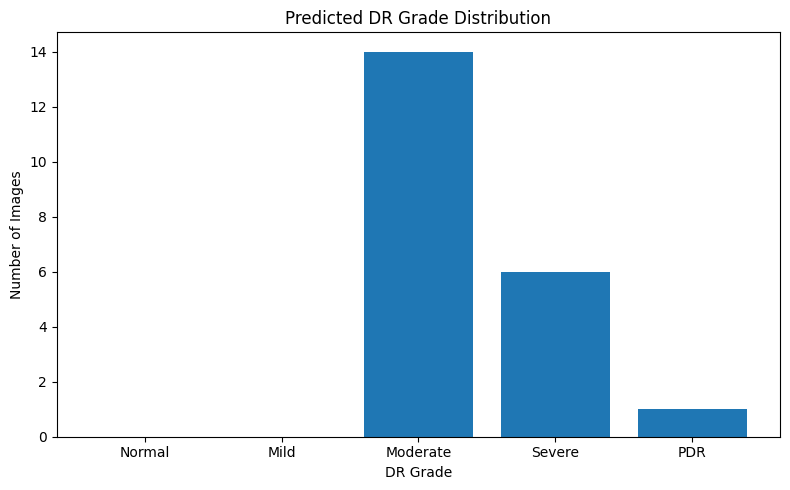

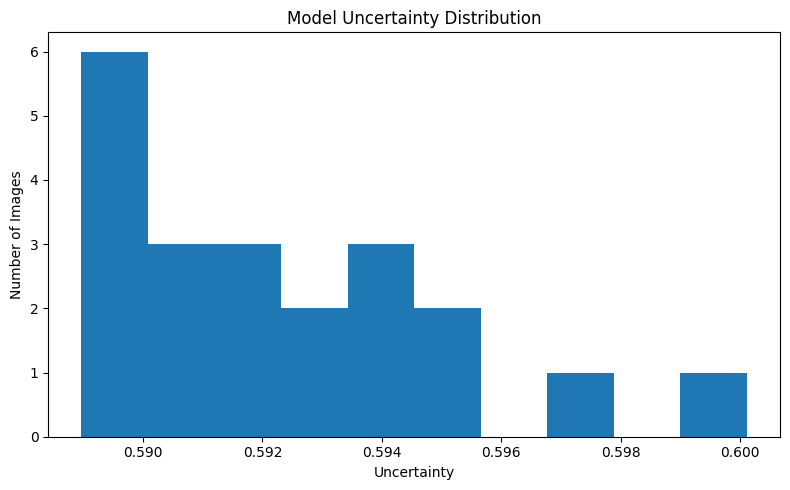

In [72]:


from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    mean_absolute_error, confusion_matrix,
    classification_report
)

proposed_model.eval()

preds = []
targets = []
uncertainties = []

# ------------------------------------------------------------
# FINAL VALIDATION PREDICTION
# ------------------------------------------------------------

with torch.no_grad():

    for start in range(0, len(val_features), 8):

        gf = val_features[start:start+8].float().to(DEVICE)
        lf = val_graph_features[start:start+8].float().to(DEVICE)

        logits, uncertainty = proposed_model(gf, lf)

        # CORAL ordinal prediction
        probabilities = torch.sigmoid(logits)

        prediction = (probabilities > 0.5).sum(dim=1)

        preds.extend(prediction.cpu().numpy())
        uncertainties.extend(
            uncertainty.mean(dim=-1).cpu().numpy()
            if uncertainty.ndim > 1
            else uncertainty.cpu().numpy()
        )

targets = val_labels.cpu().numpy()
preds = np.array(preds)
uncertainties = np.array(uncertainties)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(targets, preds)
macro_f1 = f1_score(
    targets, preds,
    average="macro",
    zero_division=0
)

qwk = cohen_kappa_score(
    targets, preds,
    weights="quadratic"
)

mae = mean_absolute_error(targets, preds)

# ------------------------------------------------------------
# FINAL RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FINAL UALGR + CORAL MODEL RESULTS")
print("=" * 65)

print(f"Validation Images   : {len(targets)}")
print(f"Correct Predictions : {(targets == preds).sum()}")
print(f"Incorrect Predictions: {(targets != preds).sum()}")
print(f"Accuracy             : {accuracy * 100:.2f}%")
print(f"Macro F1             : {macro_f1:.4f}")
print(f"QWK                  : {qwk:.4f}")
print(f"MAE                  : {mae:.4f}")
print(f"Mean Uncertainty     : {uncertainties.mean():.4f}")

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    targets,
    preds,
    labels=[0, 1, 2, 3, 4]
)

print("\n" + "=" * 65)
print("CONFUSION MATRIX")
print("=" * 65)
print(cm)

# ------------------------------------------------------------
# CLASS-WISE RESULTS
# ------------------------------------------------------------

classes = [
    "Normal",
    "Mild",
    "Moderate",
    "Severe",
    "PDR"
]

print("\n" + "=" * 65)
print("CLASS-WISE PERFORMANCE")
print("=" * 65)

for i, name in enumerate(classes):

    total = cm[i].sum()
    correct = cm[i, i]

    score = (
        correct / total * 100
        if total > 0 else 0
    )

    print(
        f"{name:<12} | "
        f"Actual: {total:2d} | "
        f"Correct: {correct:2d} | "
        f"Accuracy: {score:6.2f}%"
    )

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("CLASSIFICATION REPORT")
print("=" * 65)

print(
    classification_report(
        targets,
        preds,
        labels=[0,1,2,3,4],
        target_names=classes,
        zero_division=0
    )
)

# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=classes,
    yticklabels=classes,
    linewidths=1
)

plt.title("UALGR + CORAL DR Grade Confusion Matrix")
plt.xlabel("Predicted Grade")
plt.ylabel("Actual Grade")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PREDICTION DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

counts = [
    np.sum(preds == i)
    for i in range(5)
]

plt.bar(classes, counts)

plt.title("Predicted DR Grade Distribution")
plt.xlabel("DR Grade")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# UNCERTAINTY
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    uncertainties,
    bins=10
)

plt.title("Model Uncertainty Distribution")
plt.xlabel("Uncertainty")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# SAVE FINAL RESULTS
# ------------------------------------------------------------

results = pd.DataFrame({
    "True_Grade": targets,
    "Predicted_Grade": preds,
    "Uncertainty": uncertainties
})

results.to_csv(
    RESULTS_DIR / "FINAL_MODEL_RESULTS.csv",
    index=False
)

torch.save(
    proposed_model.state_dict(),
    RESULTS_DIR / "UALGR_CORAL_FINAL_MODEL.pt"
)
